In [1]:
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [2]:
def correlation2d(img, kernel):
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    output = np.zeros_like(img, dtype=float)

    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)
    return output

In [3]:
def convolution2d(img, kernel):
    # Flip kernel horizontally & vertically
    kernel_flipped = np.flipud(np.fliplr(kernel))
    return correlation2d(img, kernel_flipped)

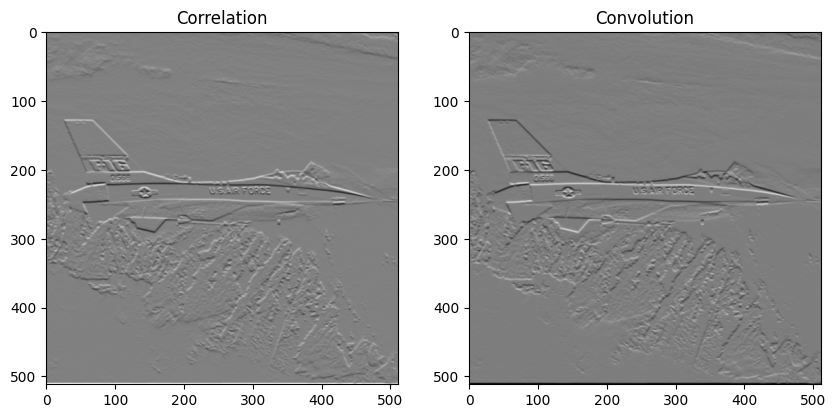

In [5]:
img = cv2.imread(r"C:\Users\hp\Downloads\airplane.bmp", cv2.IMREAD_GRAYSCALE)
kernel = np.array([[1, 2, 3],
                   [0, 0, 0],
                   [-1, -2, -3]])

corr_result = correlation2d(img, kernel)
conv_result = convolution2d(img, kernel)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(corr_result, cmap='gray'); plt.title("Correlation")
plt.subplot(1,2,2); plt.imshow(conv_result, cmap='gray'); plt.title("Convolution")
plt.show()

In [6]:
def add_gaussian_noise(img, mean=0, sigma=20):
    gauss = np.random.normal(mean, sigma, img.shape).astype('float32')
    noisy = img.astype('float32') + gauss
    return np.clip(noisy, 0, 255).astype('uint8')

In [7]:
def add_salt_pepper_noise(img, prob=0.02):
    noisy = img.copy()
    total = img.size
    num_salt = int(prob * total / 2)
    num_pepper = int(prob * total / 2)

    # Salt (white pixels)
    coords = [np.random.randint(0, i-1, num_salt) for i in img.shape]
    noisy[tuple(coords)] = 255

    # Pepper (black pixels)
    coords = [np.random.randint(0, i-1, num_pepper) for i in img.shape]
    noisy[tuple(coords)] = 0
    return noisy

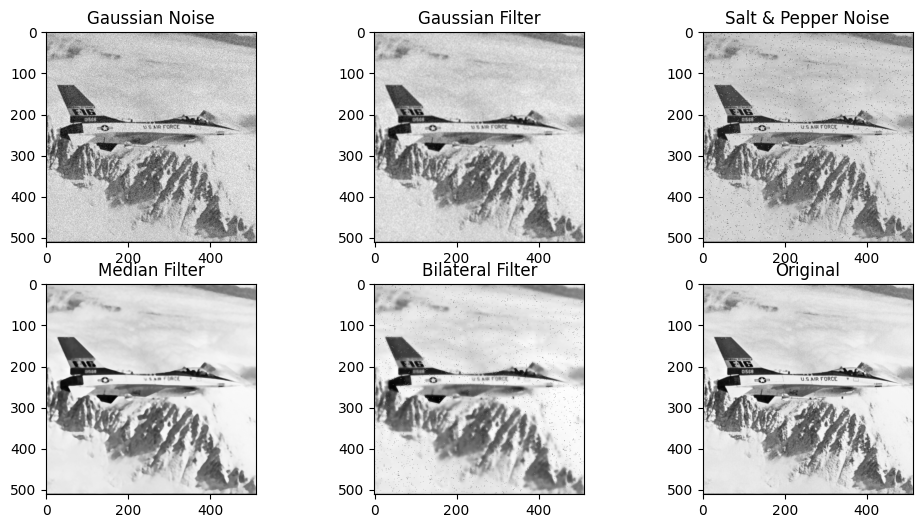

In [10]:
# Add noise
gauss_img = add_gaussian_noise(img)
sp_img = add_salt_pepper_noise(img)

# Filtering
gauss_filtered = cv2.GaussianBlur(gauss_img, (5,5), 1)
median_filtered = cv2.medianBlur(sp_img, 5)
bilateral_filtered = cv2.bilateralFilter(sp_img, 9, 75, 75)

# Show results
plt.figure(figsize=(12,6))
plt.subplot(2,3,1); plt.imshow(gauss_img, cmap='gray'); plt.title("Gaussian Noise")
plt.subplot(2,3,2); plt.imshow(gauss_filtered, cmap='gray'); plt.title("Gaussian Filter")
plt.subplot(2,3,3); plt.imshow(sp_img, cmap='gray'); plt.title("Salt & Pepper Noise")
plt.subplot(2,3,4); plt.imshow(median_filtered, cmap='gray'); plt.title("Median Filter")
plt.subplot(2,3,5); plt.imshow(bilateral_filtered, cmap='gray'); plt.title("Bilateral Filter")
plt.subplot(2,3,6); plt.imshow(img, cmap='gray'); plt.title("Original")
plt.show()

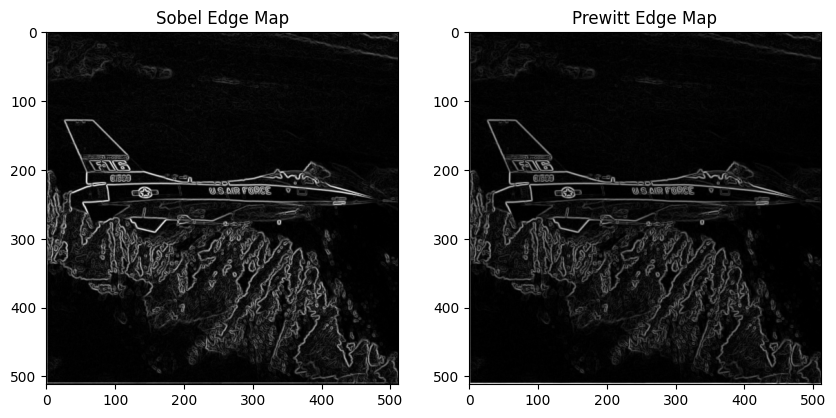

In [11]:
# Sobel
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = np.sqrt(sobelx**2 + sobely**2)

# Prewitt (manual using kernels)
prewitt_x = np.array([[-1,0,1], [-1,0,1], [-1,0,1]])
prewitt_y = np.array([[1,1,1], [0,0,0], [-1,-1,-1]])

prewittx = correlation2d(img, prewitt_x)
prewitty = correlation2d(img, prewitt_y)
prewitt_mag = np.sqrt(prewittx**2 + prewitty**2)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(sobel_mag, cmap='gray'); plt.title("Sobel Edge Map")
plt.subplot(1,2,2); plt.imshow(prewitt_mag, cmap='gray'); plt.title("Prewitt Edge Map")
plt.show()